In [34]:
import pandas as pd
import geopandas as gpd
import numpy as np
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

import pygris
import census

import requests

import os


# main crash data

crash_data = gpd.read_file("raw-data/PennDOT Crash Data/collision_crash_2020_2024.geojson")
crash_data.head(10)

print(crash_data.crs) # 4326


# centerline

center_line_data = gpd.read_file("raw-data/Street Centerline Data/Street_Centerline.geojson")

print(center_line_data.crs) # 4326

# curbs with cartways

curbs_with_cartways = gpd.read_file("raw-data/Curbs and Cartways/Curbs.geojson")
print(curbs_with_cartways.head(10))
print(curbs_with_cartways.crs) # 4326

# calming devices

traffic_calming_devices = gpd.read_file("raw-data/Traffic Calming Devices/traffic_calming_devices.geojson")
print("Calming: \n")
print(traffic_calming_devices.columns)
print(traffic_calming_devices.head(10))
print(traffic_calming_devices.crs) # 4326
# TODO: get unique values and add readable map

intersection_controls = gpd.read_file("raw-data/Intersection Controls/Intersection_Controls.geojson")
print("intersections: \n")
print(intersection_controls.columns)
print(intersection_controls.head(10))
print(intersection_controls.crs)


EPSG:4326
EPSG:4326
   objectid curbs_poly_ curbs_poly_id  fcode  elev_1  elev_2  elev_3  \
0         1        None          None   9999  1000.0     NaN     NaN   
1         2        None          None   1012     NaN     NaN     NaN   
2         3        None          None   1012     NaN     NaN     NaN   
3         4        None          None   1032     NaN     NaN     NaN   
4         5        None          None   1032     NaN     NaN     NaN   
5         6        None          None   1012     NaN     NaN     NaN   
6         7        None          None   1032     NaN     NaN     NaN   
7         8        None          None   1032     NaN     NaN     NaN   
8         9        None          None   1012     NaN     NaN     NaN   
9        10        None          None   1032     NaN     NaN     NaN   

                    update_ add_date chg_src  cp_id  Shape__Area  \
0 2013-01-25 00:00:00+00:00     None    None  26252   411.691406   
1 2013-01-25 00:00:00+00:00     None    None  26253

In [9]:
# DVRPC Traffic counts

print("traffic counts: \n")

traffic_counts_path = "raw-data/DVRPC Traffic Count/dvrpc_2024_philly_traffic_counts.geojson"

if not os.path.exists("raw-data/DVRPC Traffic Count/dvrpc_2024_philly_traffic_counts.geojson"):
    url = "https://arcgis.dvrpc.org/portal/rest/services/transportation/trafficcounts/FeatureServer/0/query"
    params = {
        "where": "setyear=2024 AND co_name LIKE 'Phil%'",
        "outsr": 4326,
        "outfields": "*",
        "f": "geojson"
    }
    r = requests.get(url, params=params)
    counts = gpd.read_file(r.text)
    counts.to_file("raw-data/DVRPC Traffic Count/dvrpc_2024_philly_traffic_counts.geojson", driver="GeoJSON")
else: 
    counts = gpd.read_file(traffic_counts_path)

print(counts.head(10))
print(counts.columns)
print(counts.crs) # 4326




traffic counts: 

   objectid  recordnum        setdate  setyear         mcd rdprefix  route  \
0    121543     166189  1731628800000     2024  4210160104      NaN    NaN   
1    123979     170740  1710806400000     2024  4210160105        I   95.0   
2    123980     170741  1710806400000     2024  4210160105        I   95.0   
3    123981     170743  1710806400000     2024  4210160105        I   95.0   
4    123982     170744  1710288000000     2024  4210160105        I   95.0   
5    123983     170745  1710288000000     2024  4210160105        I   95.0   
6    123984     170747  1710979200000     2024  4210160105      NaN    NaN   
7    123985     170748  1710288000000     2024  4210160105        I   95.0   
8    123986     170749  1710374400000     2024  4210160105        I   95.0   
9    123987     170750  1710288000000     2024  4210160105        I   95.0   

                      road cntdir                fromlmt  \
0                levick st  north             jackson st   
1  

EPSG:2272
BoundingBox(left=2645348.0, bottom=186454.0, right=2753588.0, top=307894.0)
(0.5, 0.5)
(242880, 216480)
| 0.50, 0.00, 2645348.00|
| 0.00,-0.50, 307894.00|
| 0.00, 0.00, 1.00|
{'RASTER_DATASET': 'landcover_2018_philadelphia'}


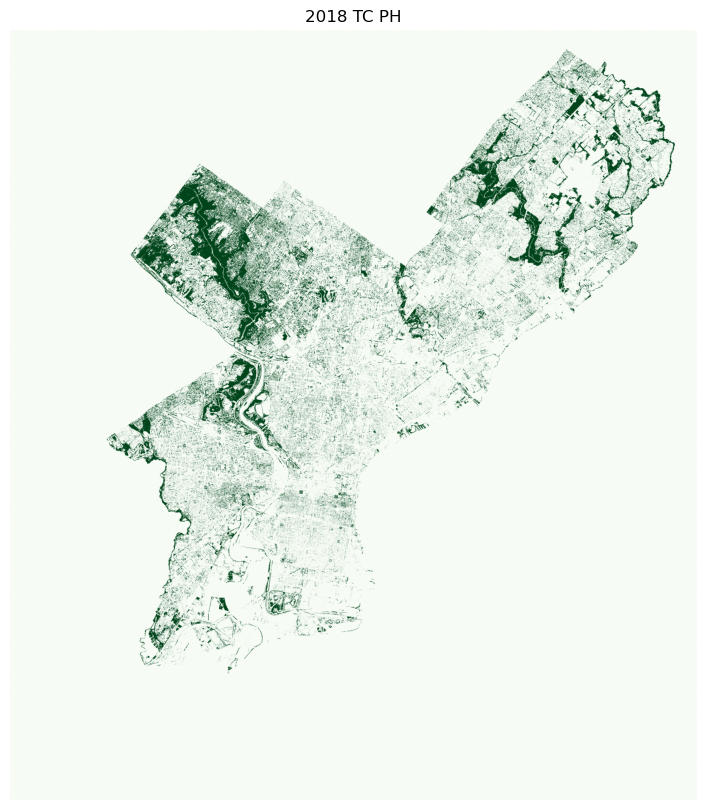

In [5]:


# Tree canopy data - CRS = 2272
# according to the site - 1 is tree canopy
with rasterio.open("raw-data/Phila Land Cover Raster/PPR_LandCover_2018.gdb") as src:
    print(src.crs) # 2722
    print(src.bounds)
    print(src.res) # 0.5 x 0.5
    print(src.shape)
    print(src.transform)
    print(src.tags())
     
    # downsample in out_shape
    data = src.read(1, out_shape=(src.height // 25, src.width // 25))

    # mask to canopy only
    canopy = np.where(data == 1, 1, 0) # why no y?

    plt.figure(figsize=(10,10))
    plt.imshow(canopy, cmap="Greens")
    plt.title("2018 TC PH")
    plt.axis("off")
    
    plt.show()

    


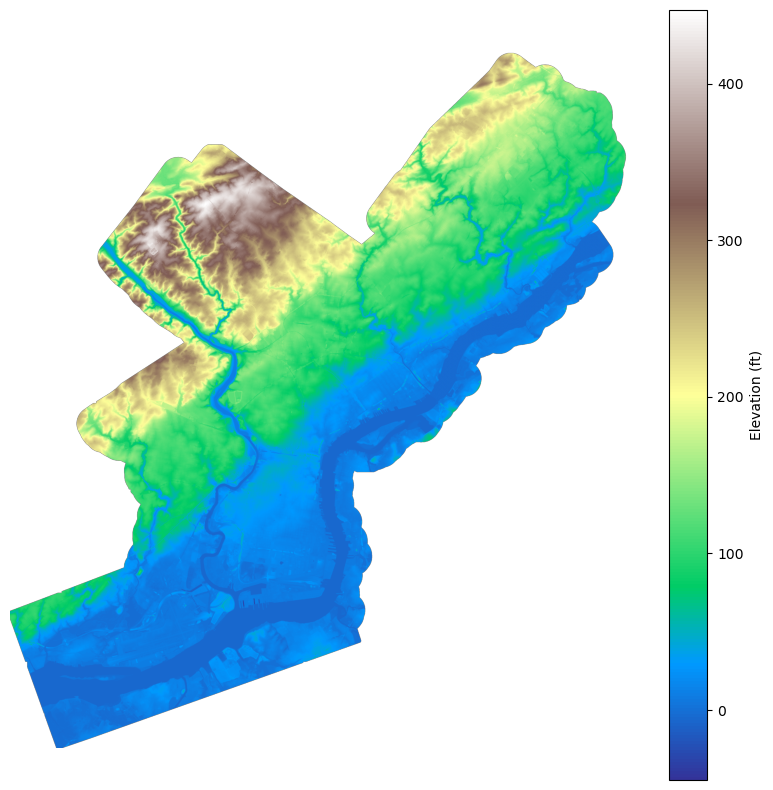

In [ ]:
print("Elevation: \n")
with rasterio.open("raw-data/Phila Elevation Raster/Philadelphia_dem_3ft_2022.tif") as src:
    data = src.read(1, out_shape=(src.height // 10, src.width // 10))
    nodata = src.nodata

data_masked = np.ma.masked_equal(data, nodata)

plt.figure(figsize=(10,10))
im = plt.imshow(data_masked, cmap="terrain")
plt.colorbar(im, label="Elevation (ft)")
plt.axis("off")
plt.show()
# TODO NEED TO CLIP!
    

PPD Street Trees 
EPSG:4326


<Axes: >

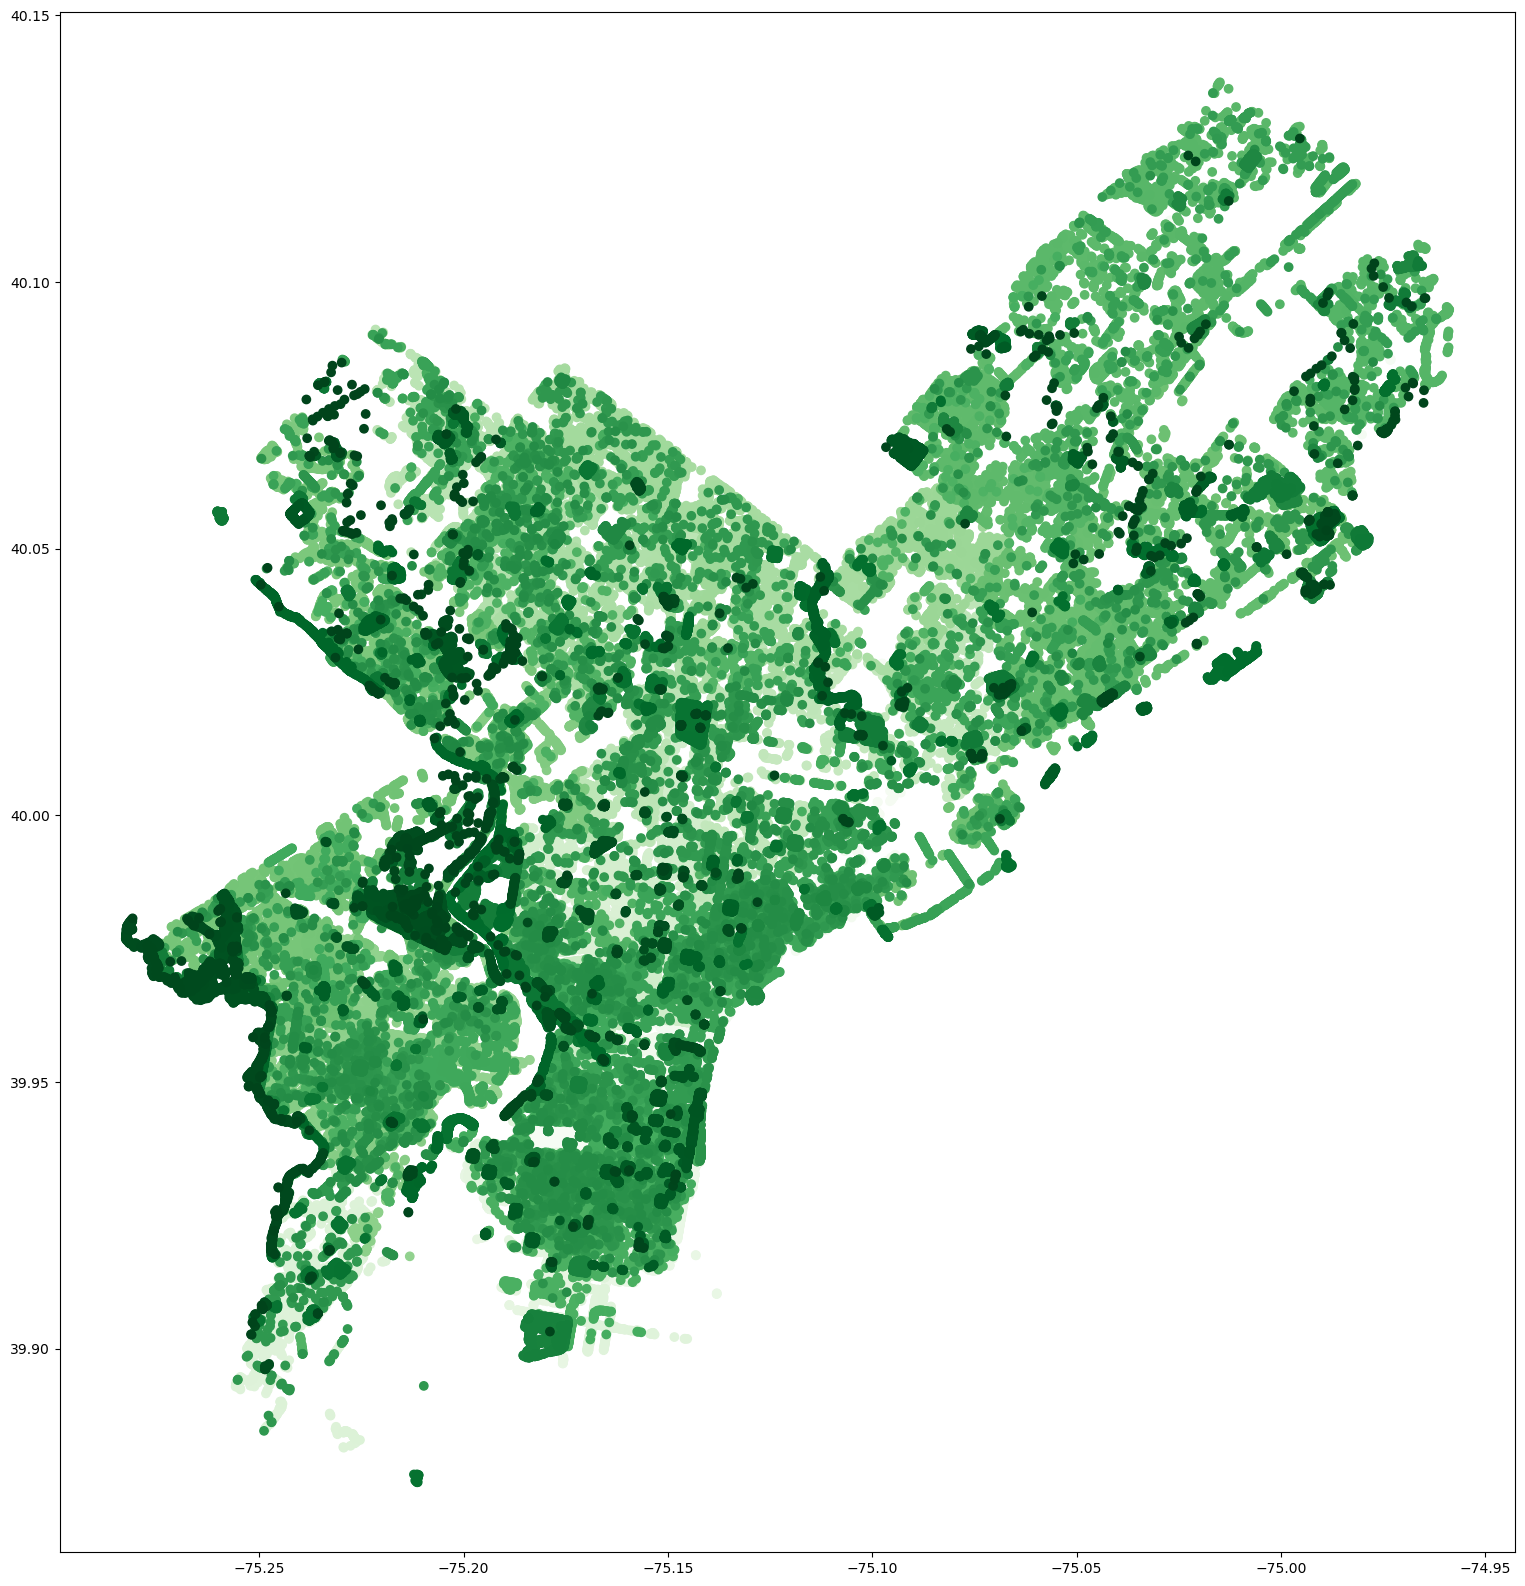

In [18]:
print("PPD Street Trees ")
tree_data = gpd.read_file("raw-data/Phila Street Trees/ppr_tree_inventory_2024.geojson")
print(tree_data.crs) # 4326
tree_data.plot(cmap="Greens", ax=None, figsize=(20,20))



In [ ]:
print("Census info: ")

block_groups_path = "raw-data/Census/phila_block_groups_2024_4269.geojson"

if not os.path.exists(block_groups_path):
    block_groups = pygris.block_groups(state="PA", county="Philadelphia", year=2024)
    block_groups.to_file(block_groups_path, driver="GeoJSON")
else:
    block_groups = gpd.read_file(block_groups_path)

print(len(block_groups))
block_groups.head(10)
print(block_groups.crs) # 4269

cen = census.Census("854998ba461ae3716c5c85301a31988051bea13e")

tract_data = cen.acs5.state_county_tract(
    fields=("NAME",
    "B19013_001E",  # median income
    "B17001_002E",  # poverty - hmmm None...
    "B01003_001E",  # population
    "B08301_001E",  # total commuters
    "B08301_003E",  # drove alone
    "B08301_010E",  # transit
    "B08301_019E",  # walked
    "B08301_021E",  # WFH
    "B02001_002E",  # white alone
    "B25002_003E",  # vacant units
    "B25058_001E",  # median rent
    "B01002_001E"),  # median age
    state_fips='42',
    county_fips="101",
    tract="*",
    year=2024
)


tract_data_df = pd.DataFrame(tract_data)
print("Tract: \n")
print(tract_data_df.head(10))

blockgroup_data = cen.acs5.state_county_blockgroup(
    fields=("NAME",
    "B19013_001E",  # median income
    "B01003_001E",  # population
    "B08301_001E",  # total commuters
    "B08301_003E",  # drove alone
    "B08301_010E",  # transit
    "B08301_019E",  # walked
    "B08301_021E",  # WFH
    "B02001_002E",  # white alone
    "B25002_003E",  # vacant units
    "B25058_001E",  # median rent
    "B01002_001E"),  # median age
    state_fips='42',
    county_fips="101",
    blockgroup="*",
    year=2024
)

blockgroup_data_frame = pd.DataFrame(blockgroup_data)
print("Blockgfroup: \n")

print(blockgroup_data_frame.head(10))




Census info: 
1338
EPSG:4269
Tract: 

                                                NAME  B19013_001E  \
0  Census Tract 1.01; Philadelphia County; Pennsy...     111148.0   
1  Census Tract 1.02; Philadelphia County; Pennsy...     101033.0   
2  Census Tract 2; Philadelphia County; Pennsylvania     102670.0   
3  Census Tract 3; Philadelphia County; Pennsylvania     102104.0   
4  Census Tract 4.01; Philadelphia County; Pennsy...      92182.0   
5  Census Tract 4.03; Philadelphia County; Pennsy...     167188.0   
6  Census Tract 4.04; Philadelphia County; Pennsy...      96024.0   
7  Census Tract 5; Philadelphia County; Pennsylvania      69677.0   
8  Census Tract 6; Philadelphia County; Pennsylvania     126033.0   
9  Census Tract 7.01; Philadelphia County; Pennsy...      85550.0   

   B17001_002E  B01003_001E  B08301_001E  B08301_003E  B08301_010E  \
0         96.0       1963.0       1646.0        308.0        331.0   
1        128.0       3172.0       2487.0        793.0        2

In [ ]:
print("Land usage")

land_usage = gpd.read_file("raw-data/Philly Land Use/Land_Use.geojson")
print(land_usage.crs) # 4326

Land usage
EPSG:4326
